# Measurement x=15, y=0, z=0

### TODO
- Lasso
- time-delayes readout learning (Takens) (as parameter)
- whole plane
- whole plane 3d?
- more inputs (in 3d?)

### Imports

In [145]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

from scipy.stats import randint, uniform, loguniform

import reservoirpy as rpy
from reservoirpy.nodes import Reservoir
from reservoirpy.nodes import Ridge
from reservoirpy.nodes import Input


from ppvm_py.utils import load_object

from ppvm_py.yz_slice_utils import find_closest_coordinate_index

from ppvm_py.plotting import plot_timeseries

from ppvm_py.data_processing.yz_slice import print_yz_slice_example_from_parsed_data
from ppvm_py.data_processing.utils import create_index_to_coord_map

from ppvm_py.feature_generation.sdc import symmetric_difference_coefficient
from ppvm_py.feature_generation.pdm import pdm_approximated_velocity

### General Args

In [146]:
random_seed = 4629837

# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 300

if Ha == 300:
    slice_folder_path = Path("../../../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
elif Ha == 1000:
    slice_folder_path = Path("../../../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")

# Estimates in determining_sigma_and_magnetic_field_strength.ipynb
sigma = -1
B_z = -1

test_size = 0.3
val_size = 0.2
n_warmup_test = 100

### Preamble

In [147]:
mses = {}  # Dict for gathering mean-squared-errors.

np.random.seed(random_seed)

### Load Data

In [148]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [149]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
fld_data['index_to_coord_map'] = create_index_to_coord_map(fld_data['coord_to_index_map'])
print_yz_slice_example_from_parsed_data(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
gradF_data['index_to_coord_map'] = create_index_to_coord_map(gradF_data['coord_to_index_map'])
print_yz_slice_example_from_parsed_data(gradF_data)

n_t, n_y, n_z, n_v = fld_data['timeseries'].shape  # N = num snapshots

The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 46, n_z (grid width) = 46, n_v (number of variables) = 8
Labels:
['vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Preview of the first snapshot (first 2 y, first 2 z) with coordinates:
  (y=-1.00, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.027423e-01  0.000000e+00
  0.000000e+00 -5.862112e-04  1.594463e+00]
  (y=-1.00, z=-0.99): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.175437e-01  0.000000e+00
 -4.764620e-01 -5.860972e-04  1.599692e+00]
  (y=-0.99, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -1.220912e-01  2.072063e+00
  0.000000e+00 -5.841985e-04  1.580085e+00]
  (y=-0.99, z=-0.99): [ 2.256158e+00 -1.132797e-01  1.513446e-02 -2.226841e-01 -5.704941e-02
 -3.949543e-01 -5.842091e-04  1.584242e+00]

The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 46, n_z (grid width) = 46, n_v (number of variables) = 3
Labels:
['dfdx', 'dfdy', 'dfdz']
Preview of the first

### Get Existing x and y Coordinates

In [150]:
y_coord_desired = 0
z_coord_desired = 0

# Adjust according to error message. No error will be thrown after correct adjustment.
# y_coord = y_coord_desired
# z_coord = z_coord_desired
if Ha == 300:
    y_coord = -0.01842125
    z_coord = -0.01842125
elif Ha == 1000:
    y_coord = 0
    z_coord = 0

i_y_center, i_z_center = find_closest_coordinate_index(
    fld_data['coord_to_index_map'],
    y_coord=y_coord,
    z_coord=z_coord,
)
output_indices = (
    slice(None),
    i_y_center,
    i_z_center,
)

### Define Train, Test, Train_Val and Val Set

In [151]:
fld_data_train, fld_data_test = train_test_split(
    fld_data['timeseries'],
    test_size=test_size,
    shuffle=False,
)
fld_data_train_val, fld_data_val = train_test_split(
    fld_data_train,
    test_size=0.2,
    shuffle=False,
)

# train
output_indices_shape_train = fld_data_train[output_indices].shape[:-1]
n_output_indices_train = int(np.prod(list(output_indices_shape_train)))

# test
output_indices_shape_test = fld_data_test[output_indices].shape[:-1]
n_output_indices_test = int(np.prod(list(output_indices_shape_test)))
n_time_output_indices_test = output_indices_shape_test[0]
n_spatial_output_indices_test = int(np.prod(output_indices_shape_test[1:]))

# train_val
output_indices_shape_train_val = fld_data_train_val[output_indices].shape[:-1]
n_output_indices_train_val = int(np.prod(list(output_indices_shape_train_val)))

# val
output_indices_shape_val = fld_data_val[output_indices].shape[:-1]
n_output_indices_val = int(np.prod(list(output_indices_shape_val)))

### Define $y_{\text{true}}$

In [152]:
# train
y_true_train = fld_data_train[
    ...,
    fld_data['labels'].index('vx'),
]

# Train SS on all training data to make it comparable to other output_indices.
# Every grid point is an output feature. The scaling must not be different between these features => train SS on all data together.
ss_y_true = StandardScaler()
ss_y_true.fit(y_true_train.reshape(-1, 1))

y_true_train = y_true_train[output_indices]
y_true_train = ss_y_true.transform(
    y_true_train.reshape(-1, 1),
).reshape(*output_indices_shape_train)


# test
y_true_test = fld_data_test[
    ...,
    fld_data['labels'].index('vx'),
]
y_true_test = y_true_test[output_indices]
y_true_test = ss_y_true.transform(
    y_true_test.reshape(-1, 1),
).reshape(*output_indices_shape_test)

### Get Input $\phi$

In [153]:
# phi_standard_scaler
phi_train = fld_data_train[
    ...,
    fld_data['labels'].index('F'),
]
ss_phi = StandardScaler()
ss_phi.fit(phi_train.reshape(-1, 1))

# train
shape_ = phi_train.shape
phi_train = ss_phi.transform(phi_train.reshape(-1, 1)).reshape(shape_)

# test
phi_test = fld_data_test[
    ...,
    fld_data['labels'].index('F'),
]
shape_ = phi_test.shape
phi_test = ss_phi.transform(phi_test.reshape(-1, 1)).reshape(shape_)

### General Benchmark

Assuming we know $j_y$ and the measurement distance of potentials can be infinitesimal small, we can use the partial derivative $\frac{\partial{\phi}}{\partial{y}}$ of the potential. With this, we can calculate the $v_x$ exactly using Ohm's law. The remainder is simulation error.

This error is taken as benchmark to compare all methods against.

mse(part + j) = 0.02579092683066761


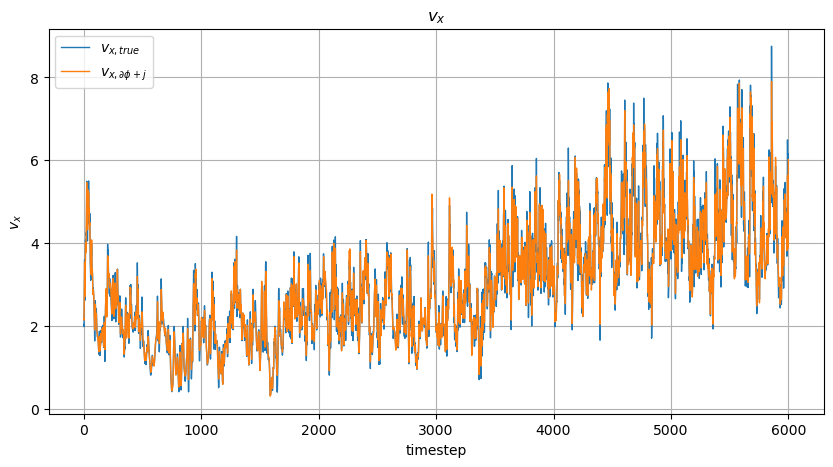

In [154]:
part_phi_y = gradF_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    gradF_data['labels'].index('dfdy'):gradF_data['labels'].index('dfdy') + 1,
]
j_y_center = fld_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    fld_data['labels'].index('jy'):fld_data['labels'].index('jy') + 1,
]

(
    part_phi_y_train,
    part_phi_y_test,
    j_y_center_train,
    j_y_center_test
) = train_test_split(
    part_phi_y,
    j_y_center,
    test_size=test_size,
    shuffle=False,
)
v_x_ohms_law_test = (part_phi_y_test - (j_y_center_test / sigma)) / B_z
y_pred_ohms_law_test = ss_y_true.transform(
    v_x_ohms_law_test,
    copy=False,
)
mse_ohms_law = mean_squared_error(
    y_true_test[n_warmup_test:],
    y_pred_ohms_law_test[n_warmup_test:],
)
mses['General Benchmark'] = mse_ohms_law
print(f"mse(part + j) = {mse_ohms_law}")
plot_timeseries(
    data_list=[
        y_true_test,
        y_pred_ohms_law_test,
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, \\partial{\\phi} + j}$",
    ],
    title="$v_x$",
    xlabel="timestep",
    ylabel="$v_x$",
)

### Potential Difference Method (SDC) Benchmark
Assume we know $j_y$, but we are restricted the the potential measurements $\phi$ from our DNS.

A simple feature used in the experiments is the symmetric difference coefficient $\frac{\Delta{\phi}}{\Delta{y}}$ to approximate $\frac{\partial{\phi}}{\partial{y}}$. This is also called *Potential Difference Method*. With this and $j_y$, Ohm's law can be approximated to calculate $v_x$.

We use the smallest difference possible to calculate $\frac{\Delta{\phi}}{\Delta{y}}$. With this, we have a benchmark for methods that use the Symmetric Difference Coefficient as singular feature.

##### Define Points $y_1$ and $y_2$

y_1_y = (y_1_y, y_1_z)

y_2_y = (y_2_y, y_2_z)

y_1_y < y_coord < y_2_y

y_1_z = z_coord = y_2_z

In [155]:
# """Coordinates by using delta_l
# """

# delta_l = 0.1  # y, z domain = [-1, 1]


# # Find y_1
# y_1_y_desired = y_coord - delta_l / 2
# y_1_z_desired = z_coord

# # Adjust according to error message. No error will be thrown after correct adjustment.
# # y_1_y = y_1_y_desired
# # y_1_z = y_1_z_desired
# if Ha == 300:
#     y_1_y = -0.05560156
#     y_1_z = -0.01842125
# elif Ha == 1000:
#     y_1_y = -0.03460649
#     y_1_z = 0.0

# i_y_1_y, i_y_1_z = find_closest_coordinate_index(
#     fld_data['coord_to_index_map'],
#     y_coord=y_1_y,
#     z_coord=y_1_z,
#     )


# # Find y_2
# y_2_y_desired = y_coord + delta_l / 2
# y_2_z_desired = z_coord

# # Adjust according to error message. No error will be thrown after correct adjustment.
# # y_2_y = y_2_y_desired
# # y_2_z = y_2_z_desired
# if Ha == 300:
#     y_2_y = 0.01842125
#     y_2_z = -0.01842125
# elif Ha == 1000:
#     y_2_y = 0.03460649
#     y_2_z = 0.0

# i_y_2_y, i_y_2_z = find_closest_coordinate_index(
#     fld_data['coord_to_index_map'],
#     y_coord=y_2_y,
#     z_coord=y_2_z,
#     )

In [156]:
"""Coordinates by using delta_i
"""

delta_i = 1


i_y_1_y = i_y_center - delta_i
i_y_1_z = i_z_center

i_y_2_y = i_y_center + delta_i
i_y_2_z = i_z_center

y_1_y, y_1_z = fld_data['index_to_coord_map'][i_y_1_y, i_y_1_z]
y_2_y, y_2_z = fld_data['index_to_coord_map'][i_y_2_y, i_y_2_z]

In [157]:
"""Coordinate Checkup
"""
print(f"Center: y = {fld_data['index_to_coord_map'][i_y_center, i_z_center]}, z = {fld_data['index_to_coord_map'][i_y_center, i_z_center]}")
print()
print(f"y_1 Coordinates: y = {y_1_y}, z = {y_1_z}")
print(f"Difference to center: ", end='')
print(f"delta_y^y_1 = {y_1_y - y_coord}, delta_z^y_1 = {y_1_z - z_coord}, ", end='')
print(f"delta_i_y^y_1 = {i_y_1_y - i_y_center}, delta_i_z^y_1 = {i_y_1_z - i_z_center}")
print()
print(f"y_2 Coordinates: y = {y_2_y}, z = {y_2_z}")
print(f"Difference to center: ", end='')
print(f"delta_y^y_2 = {y_2_y - y_coord}, delta_z^y_2 = {y_2_z - z_coord}, ", end='')
print(f"delta_i_y^y_2 = {i_y_2_y - i_y_center}, delta_i_z^y_2 = {i_y_2_z - i_z_center}")
print()
delta_y = y_2_y - y_1_y
delta_z = y_2_z - y_1_z
print(f"Difference between y_1 to y_2: ", end='')
print(f"delta_y = {delta_y}, delta_z = {delta_z}, ", end='')
print(f"delta_i_y = {i_y_2_y - i_y_1_y}, delta_i_z = {i_y_2_z - i_y_1_z}")

Center: y = (-0.01842125, -0.01842125), z = (-0.01842125, -0.01842125)

y_1 Coordinates: y = -0.05560156, z = -0.01842125
Difference to center: delta_y^y_1 = -0.03718031, delta_z^y_1 = 0.0, delta_i_y^y_1 = -1, delta_i_z^y_1 = 0

y_2 Coordinates: y = 0.01842125, z = -0.01842125
Difference to center: delta_y^y_2 = 0.0368425, delta_z^y_2 = 0.0, delta_i_y^y_2 = 1, delta_i_z^y_2 = 0

Difference between y_1 to y_2: delta_y = 0.07402281, delta_z = 0.0, delta_i_y = 2, delta_i_z = 0


##### Prepare Data

In [158]:
# train
phi_y_1_train = phi_train[
    :,
    i_y_1_y,
    i_y_1_z,
]
phi_y_2_train = phi_train[
    :,
    i_y_2_y,
    i_y_2_z,
]

# test
phi_y_1_test = phi_test[
    :,
    i_y_1_y,
    i_y_1_z,
]
phi_y_2_test = phi_test[
    :,
    i_y_2_y,
    i_y_2_z,
]

##### Testing

mse(pdm_j) = 0.10540168895889483


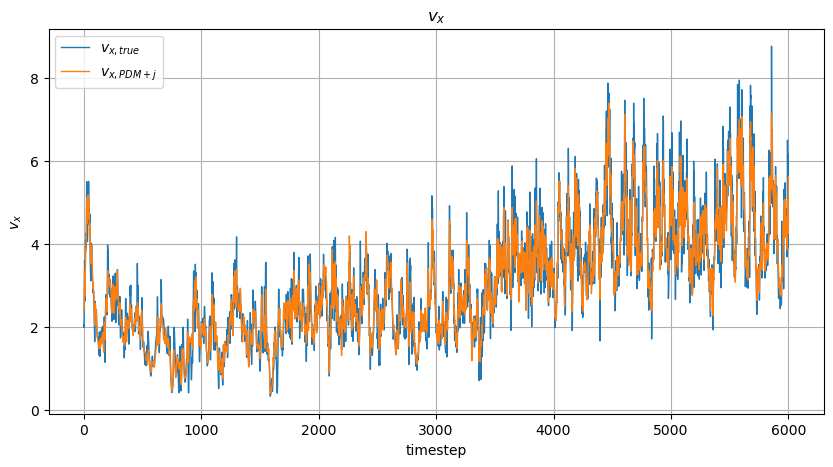

In [159]:
approx_part_phi_y_test = symmetric_difference_coefficient(
    former_point=ss_phi.inverse_transform(phi_y_1_test.reshape(-1, 1)),
    latter_point=ss_phi.inverse_transform(phi_y_2_test.reshape(-1, 1)),
    delta_l=delta_y,
).reshape(-1, 1)
v_x_sdc_test = (approx_part_phi_y_test - (j_y_center_test / sigma)) / B_z
y_pred_sdc_test = ss_y_true.transform(
    v_x_sdc_test,
    copy=False,
)
mse_sdc = mean_squared_error(
    y_true_test.reshape(
        n_time_output_indices_test,
        n_spatial_output_indices_test,
    )[n_warmup_test:],
    y_pred_sdc_test.reshape(
        n_time_output_indices_test,
        n_spatial_output_indices_test,
    )[n_warmup_test:],
)
mses['PDM Benchmark'] = mse_sdc
print(f"mse(pdm_j) = {mse_sdc}")
plot_timeseries(
    data_list=[
        y_true_test,
        y_pred_sdc_test,
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, PDM + j}$",
    ],
    title="$v_x$",
    xlabel="timestep",
    ylabel="$v_x$",
)

### Echo State Network + Lasso

In [ ]:
class ESNRidge(BaseEstimator, RegressorMixin):
    """
    A scikit-learn–compatible wrapper for an Echo State Network.
    """

    def __init__(
        self,
        n_hidden_neurons=200,
        neuron_leak_rate=0.3,
        w_spectral_radius=0.9,
        input_scaling=1.0,
        regularization_scale=1e-6,
        n_warmup_fit=100,
        n_warmup_pred=100,
        rpy_verbosity=0,
        random_state=None,
    ):
        self.n_hidden_neurons    = n_hidden_neurons
        self.neuron_leak_rate    = neuron_leak_rate
        self.w_spectral_radius   = w_spectral_radius
        self.input_scaling       = input_scaling
        self.regularization_scale= regularization_scale
        self.n_warmup_fit        = n_warmup_fit
        self.n_warmup_pred       = n_warmup_pred
        self.rpy_verbosity       = rpy_verbosity
        self.random_state        = random_state
        self.esn_                = None

    def fit(self, X, y):
        # 1) Set RPy verbosity & seed
        rpy.verbosity(self.rpy_verbosity)
        if self.random_state is not None:
            np.random.seed(self.random_state)
            rpy.set_seed(self.random_state)

        # 2) Build reservoir + readout
        reservoir = Reservoir(
            units=self.n_hidden_neurons,
            lr=self.neuron_leak_rate,
            sr=self.w_spectral_radius,
            input_scaling=self.input_scaling,
        )
        self._reservoir_name = reservoir.name

        readout = Ridge(ridge=self.regularization_scale)
        self._readout_name = readout.name

        inp = Input()
        self.esn_ = [inp, inp >> reservoir] >> readout

        # 3) Initialize with the first time-step
        self.esn_.initialize(X[0], y.reshape(-1, 1)[0])

        # 4) Create a reproducible initial state for warm-up
        self.init_state = np.random.uniform(
            -1, 1, size=(1, reservoir.output_dim)
        )

        # 5) Fit on the entire training series, with warm-up
        self.esn_ = self.esn_.fit(
            X,
            y.reshape(-1, 1),
            warmup=self.n_warmup_fit,
            from_state={reservoir.name: self.init_state},
        )
        return self

    def predict(self, X):
        y_pred_states = self.esn_.run(
            X,
            from_state={self._reservoir_name: self.init_state},
            return_states=[self._readout_name],
        )
        y_pred = y_pred_states[self._readout_name]
        return y_pred.ravel()


    def get_params(self, deep=True):
        return {
            "n_hidden_neurons":     self.n_hidden_neurons,
            "neuron_leak_rate":     self.neuron_leak_rate,
            "w_spectral_radius":    self.w_spectral_radius,
            "input_scaling":        self.input_scaling,
            "regularization_scale": self.regularization_scale,
            "n_warmup_fit":         self.n_warmup_fit,
            "n_warmup_pred":        self.n_warmup_pred,
            "rpy_verbosity":        self.rpy_verbosity,
            "random_state":         self.random_state,
        }

    def set_params(self, **params):
        for key, value in params.items():
            if not hasattr(self, key):
                raise ValueError(f"Unknown parameter '{key}' for ESNRegressor")
            setattr(self, key, value)
        return self
    
    def score(self, X, y_true):
        y_pred = self.predict(X)
        k = self.n_warmup_pred
        return -mean_squared_error(y_true[k:], y_pred[k:])

class GlobalStandardScaler(BaseEstimator, TransformerMixin):
    """
    Compute a single mean and standard deviation over all entries of X,
    then standardize every element in X by (X - mean) / std.
    """

    def __init__(self):
        # placeholders
        self.mean_ = None
        self.scale_ = None

    def fit(self, X, y=None):
        # X: array‐like of shape (n_samples, n_channels)
        # flatten to compute global stats
        flat = np.asarray(X).ravel()
        self.mean_ = flat.mean()
        self.scale_ = flat.std(ddof=0)
        if self.scale_ == 0:
            raise ValueError("GlobalStandardScaler: found zero variance in X")
        return self

    def transform(self, X):
        X = np.asarray(X)
        return (X - self.mean_) / self.scale_

    def inverse_transform(self, X):
        X = np.asarray(X)
        return X * self.scale_ + self.mean_

base_pipeline = Pipeline([
    ("scaler", GlobalStandardScaler()),   # or StandardScaler for inputs
    ("esn", ESNRidge(
        n_warmup_fit=100,
        n_warmup_pred=100,
        rpy_verbosity=0,
        random_state=random_seed,
    ))
])
pipeline = TransformedTargetRegressor(
    regressor=base_pipeline,
    transformer=StandardScaler(),  # fits on y_train, applies to y in fit/predict internally
)


# 2) Choose a time‐series CV splitter
tscv = TimeSeriesSplit(n_splits=2)


# 3) Define your hyper‐parameter distributions
param_dist = {
    "regressor__esn__n_hidden_neurons":    randint(10, 500),
    "regressor__esn__neuron_leak_rate":    uniform(0.02, 1.0),
    "regressor__esn__w_spectral_radius":   loguniform(0.1, 10),
    "regressor__esn__input_scaling":       loguniform(0.1, 10.0),
    "regressor__esn__regularization_scale":loguniform(1e-6, 1e3),
}


# 4) Set up the RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=2000,
    cv=tscv,
    scoring=None,   # uses regressor.score → ESNRidge.score
    n_jobs=-1,
    verbose=4,
    random_state=random_seed,
)


# 5) Fit on your full train set (fld_data_train)
# X_train
phi_train = fld_data_train[
    ...,
    fld_data['labels'].index('F'),
]

phi_y_1_train = phi_train[
    :,
    i_y_1_y,
    i_y_1_z,
]
phi_y_2_train = phi_train[
    :,
    i_y_2_y,
    i_y_2_z,
]
phi_center_train = phi_train[
    :,
    i_y_center,
    i_z_center,
]

X_train = np.stack(
    [
        phi_center_train,
        phi_y_1_train,
        phi_y_2_train,
    ],
    axis=1,
)

# y_train
y_true_train = fld_data_train[
    ...,
    fld_data['labels'].index('vx'),
]
y_true_train = y_true_train[output_indices]
y_train = y_true_train.reshape(-1, 1)

random_search.fit(X_train, y_train)


# 6) Inspect the results
print("Best CV MSE: {:.5f}".format(-random_search.best_score_))
print("Best hyper‐parameters:")
for k, v in random_search.best_params_.items():
    print(f"  • {k}: {v}")


# 7) Test
# X_test
phi_test = fld_data_test[
    ...,
    fld_data['labels'].index('F'),
]

phi_y_1_test = phi_test[
    :,
    i_y_1_y,
    i_y_1_z,
]
phi_y_2_test = phi_test[
    :,
    i_y_2_y,
    i_y_2_z,
]
phi_center_test = phi_test[
    :,
    i_y_center,
    i_z_center,
]

X_test = np.stack(
    [
        phi_center_test,
        phi_y_1_test,
        phi_y_2_test,
    ],
    axis=1,
)

# y_test
y_true_test = fld_data_test[
    ...,
    fld_data['labels'].index('vx'),
]
y_true_test = y_true_test[output_indices]
y_test = y_true_test.reshape(-1, 1)

best_model = random_search.best_estimator_
y_pred_esn_ridge_test = best_model.predict(X_test)

_shape_temp = y_pred_esn_ridge_test.shape
y_pred_esn_ridge_test = ss_y_true.transform(
    y_pred_esn_ridge_test.reshape(-1, 1),
).reshape(_shape_temp)

_shape_temp = y_true_test.shape
y_true_test = ss_y_true.transform(
    y_true_test.reshape(-1, 1),
).reshape(_shape_temp)

n_warmup_test = 100
mse_esn_ridge = mean_squared_error(
    y_true_test[n_warmup_test:],
    y_pred_esn_ridge_test[n_warmup_test:],
)
mses['esn-ridge'] = mse_esn_ridge
print(f"mse(esn-ridge) = {mse_esn_ridge}")
plot_timeseries(
    data_list=[
        y_true_test[n_warmup_test:],
        y_pred_esn_ridge_test[n_warmup_test:],
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, esn-ridge}$",
    ],
    title="$v_x$",
    xlabel="timestep",
    ylabel="$v_x$",
)


Fitting 2 folds for each of 2000 candidates, totalling 4000 fits


### Comparison

In [ ]:
mses

{'General Benchmark': 0.025727040824984036,
 'PDM Benchmark': 0.10477532274126165,
 'esn-ridge': 0.7216476647661108}